# Training Step

Using the data loading class and VAE architecture already implemented, now we will train it with the Fashion MNIST data. 

In [217]:
import torch
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
from data_loading import FashionMNISTData
from vae import VAE

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

save_dir = Path("artifacts")
save_dir.mkdir(exist_ok=True)
(save_dir / "model").mkdir(exist_ok=True)
(save_dir / "images").mkdir(exist_ok=True)

Using device: mps


In [218]:
data = FashionMNISTData(batch_size=128, val_split=0.1, root="./data", seed=42)
train_loader, val_loader = data.train_loader, data.val_loader

In [219]:
model = VAE(latent_dim=32).to(device)
optimizer = Adam(model.parameters(), lr=5e-4)
beta = 0.0

## Helper Functions

In [220]:
def recon_loss(logits, x):
    per_elem = F.binary_cross_entropy_with_logits(logits, x, reduction="none")
    per_sample = per_elem.view(per_elem.size(0), -1).sum(dim=1)
    return per_sample.mean()

def vae_loss(xhat, x, mu, logvar, beta=beta):
    recon = recon_loss(xhat, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    return recon + beta * kl, recon.detach(), kl.detach()

In [221]:
def train_one_epoch(model, loader, opt, device, beta=beta):
    model.train()
    total, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        xhat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(xhat, x, mu, logvar, beta=beta)
        opt.zero_grad()
        loss.backward()
        opt.step()
        bs = x.size(0)
        total += loss.item() * bs
        total_recon += recon.item() * bs
        total_kl += kl.item() * bs
        n += bs
    return total / n, total_recon / n, total_kl / n

In [222]:
@torch.no_grad()
def evaluate(model, loader, device, beta=beta):
    model.eval()
    total, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        xhat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(xhat, x, mu, logvar, beta=beta)
        bs = x.size(0)
        total += loss.item() * bs
        total_recon += recon.item() * bs
        total_kl += kl.item() * bs
        n += bs
    return total / n, total_recon / n, total_kl / n

In [223]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8, save_path=None):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    logits, _, _ = model(x)
    xhat = torch.sigmoid(logits)
    x = x.cpu().numpy()
    xhat = xhat.cpu().numpy()
    fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
    for i in range(n):
        axes[0, i].imshow(x[i, 0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(xhat[i, 0], cmap="gray")
        axes[1, i].axis("off")
    axes[0,0].set_ylabel("Input", fontsize=16)
    axes[1,0].set_ylabel("Reconstruction", fontsize=16)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()

In [224]:
@torch.no_grad()
def show_prior_samples(model, device, n=16, save_path=None):
    model.eval()
    z = torch.randn(n, model.latent_dim).to(device)
    logits = model.decode(z)
    xhat = torch.sigmoid(logits).cpu().numpy()
    cols = int(n**0.5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.ravel()
    for i in range(n):
        axes[i].imshow(xhat[i, 0], cmap="gray")
        axes[i].axis("off")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()

In [225]:
@torch.no_grad()
def latent_scatter(model, loader, device, n=3000, method="pca", save_path=None):
    model.eval()
    Xs, Ys = [], []
    seen = 0
    for x, y in loader:
        x = x.to(device)
        _, mu, _ = model(x)
        Xs.append(mu.cpu())
        Ys.append(y)
        seen += x.size(0)
        if seen >= n: break

    Z = torch.cat(Xs, dim=0)[:n].numpy()
    Y = torch.cat(Ys, dim=0)[:n].numpy()

    if method == "tsne":
        try:
            Z2 = TSNE(n_components=2, init="pca", learning_rate="auto").fit_transform(Z)
        except Exception:
            method = "pca"
    if method == "pca":
        Zt = torch.from_numpy(Z)
        Zt = Zt - Zt.mean(0, keepdim=True)
        U, S, V = torch.pca_lowrank(Zt, q=2)
        Z2 = (Zt @ V[:, :2]).numpy()

    plt.figure(figsize=(5,5))
    plt.scatter(Z2[:,0], Z2[:,1], c=Y, s=6, cmap="tab10")
    plt.axis("off")
    plt.title("Latent Space (μ) – " + method.upper())
    if save_path: 
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()

In [226]:
@torch.no_grad()
def interpolate_between(model, loader, device, steps=10, save_path=None):
    model.eval()
    x, y = next(iter(loader))
    a, b = x[0:1].to(device), x[1:2].to(device)
    mu_a, _ = model.encode(a)
    mu_b, _ = model.encode(b)
    alphas = torch.linspace(0, 1, steps, device=device).unsqueeze(1)
    z = (1 - alphas) * mu_a + alphas * mu_b
    logits = model.decode(z)
    imgs = torch.sigmoid(logits).cpu().numpy()
    fig, axes = plt.subplots(1, steps, figsize=(steps*1.2, 1.2))
    for i in range(steps):
        axes[i].imshow(imgs[i, 0], cmap="gray")
        axes[i].axis("off")
    fig.suptitle("Latent Interpolation", y=0.95)
    if save_path: 
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()

In [227]:
@torch.no_grad()
def latent_traversal(model, loader, device, dim=0, span=3.0, steps=11, save_path=None):
    model.eval()
    x, _ = next(iter(loader))
    x0 = x[0:1].to(device)
    mu, _ = model.encode(x0)
    z = mu.repeat(steps, 1)
    alphas = torch.linspace(-span, span, steps, device=device)
    z[:, dim] = alphas
    logits = model.decode(z)
    imgs = torch.sigmoid(logits).cpu().numpy()
    fig, axes = plt.subplots(1, steps, figsize=(steps*1.2, 1.2))
    for i in range(steps):
        axes[i].imshow(imgs[i, 0], cmap="gray")
        axes[i].axis("off")
    fig.suptitle(f"Latent Traversal — dim {dim}", y=0.95)
    if save_path: 
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()

In [228]:
@torch.no_grad()
def peek_stats(model, loader, device):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)
    logits, mu, logvar = model(x)
    print("mu|mean|", mu.mean().item(), "mu|std|", mu.std().item(),
          "logvar|mean|", logvar.mean().item())

In [229]:
def beta_schedule(epoch, warmup_epochs=25, max_beta=1.0):
    return min (max_beta, epoch / warmup_epochs * max_beta)

## Training

In [230]:
epochs = 50
best = float("inf")

for epoch in range(1, epochs + 1):
    beta = beta_schedule(epoch)
    tr_loss, tr_rec, tr_kl = train_one_epoch(model, train_loader, optimizer, device, beta)
    va_loss, va_rec, va_kl = evaluate(model, val_loader, device, beta)

    if va_loss < best:
        best = va_loss
        torch.save(model.state_dict(), save_dir / f"model/vae_fashion_mnist_best.pth")

    if epoch == 1:
        torch.save(model.state_dict(), save_dir / "model/vae_fashion_mnist_epoch_01.pth")

    if epoch % 10 == 0 or epoch == 1:

        peek_stats(model, val_loader, device)

        print(
            f"Epoch {epoch:02d}: "
            f"Train Loss: {tr_loss:.4f} (Recon: {tr_rec:.4f}, KL: {tr_kl:.4f}) | "
            f"Val Loss: {va_loss:.4f} (Recon: {va_rec:.4f}, KL: {va_kl:.4f})"
        )

torch.save(model.state_dict(), save_dir / "model/vae_fashion_mnist_final.pth")

mu|mean| 0.024968329817056656 mu|std| 0.44690683484077454 logvar|mean| -0.4472995400428772
Epoch 01: Train Loss: 542.0434 (Recon: 541.4511, KL: 14.8082) | Val Loss: 537.7233 (Recon: 537.4894, KL: 5.8462)
mu|mean| -0.007265155203640461 mu|std| 0.4066183567047119 logvar|mean| -0.4078899919986725
Epoch 10: Train Loss: 519.4335 (Recon: 516.7817, KL: 6.6295) | Val Loss: 518.3581 (Recon: 515.6462, KL: 6.7796)
mu|mean| -0.003639655653387308 mu|std| 0.3509470224380493 logvar|mean| -0.30176305770874023
Epoch 20: Train Loss: 521.0138 (Recon: 516.9372, KL: 5.0957) | Val Loss: 520.1235 (Recon: 516.1061, KL: 5.0218)
mu|mean| -0.0005898061208426952 mu|std| 0.3369375169277191 logvar|mean| -0.2933221757411957
Epoch 30: Train Loss: 521.5369 (Recon: 516.9354, KL: 4.6015) | Val Loss: 520.5864 (Recon: 515.9925, KL: 4.5939)
mu|mean| 0.0022623520344495773 mu|std| 0.32287272810935974 logvar|mean| -0.29111436009407043
Epoch 40: Train Loss: 521.2088 (Recon: 516.5917, KL: 4.6171) | Val Loss: 520.3874 (Recon: 51

## Evaluation Helpers

In [ ]:
import math

@torch.no_grad()
def evaluate_metrics(model, loader, device, img_size=28):
    model.eval()
    total_recon, total_kl, n = 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        logits, mu, logvar = model(x)
        per_elem = F.binary_cross_entropy_with_logits(logits, x, reduction="none")
        recon = per_elem.view(per_elem.size(0), -1).sum(dim=1).mean()
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

        bs = x.size(0)
        total_recon += recon.item() * bs
        total_kl += kl.item() * bs
        n += bs

    recon_avg = total_recon / n
    kl_avg = total_kl / n
    nelbo = recon_avg + kl_avg
    bpd = nelbo / (img_size * img_size * math.log(2))

    return {"recon": recon_avg, "kl": kl_avg, "nelbo": nelbo, "bpd": bpd}

In [232]:
@torch.no_grad()
def sample_grid(model, device, n=16, seed=0, save_path=None):
    model.eval()
    g = torch.Generator(device=device).manual_seed(seed)
    z = torch.randn(n, model.latent_dim, generator=g, device=device)
    logits = model.decode(z)
    imgs = torch.sigmoid(logits).cpu().numpy()

    cols = int(n**0.5); rows = (n + cols - 1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = np.array(axes).reshape(rows, cols)
    k = 0
    for r in range(rows):
        for c in range(cols):
            if k < n:
                axes[r, c].imshow(imgs[k, 0], cmap="gray"); axes[r, c].axis("off")
                k += 1
            else:
                axes[r, c].axis("off")
    fig.suptitle("Prior Samples (fixed seed)", y=0.98)
    if save_path: plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()


## Visualization

### Visualizing Epoch 1 Metrics

In [233]:
model.load_state_dict(torch.load(save_dir / "model/vae_fashion_mnist_epoch_01.pth"))

<All keys matched successfully>

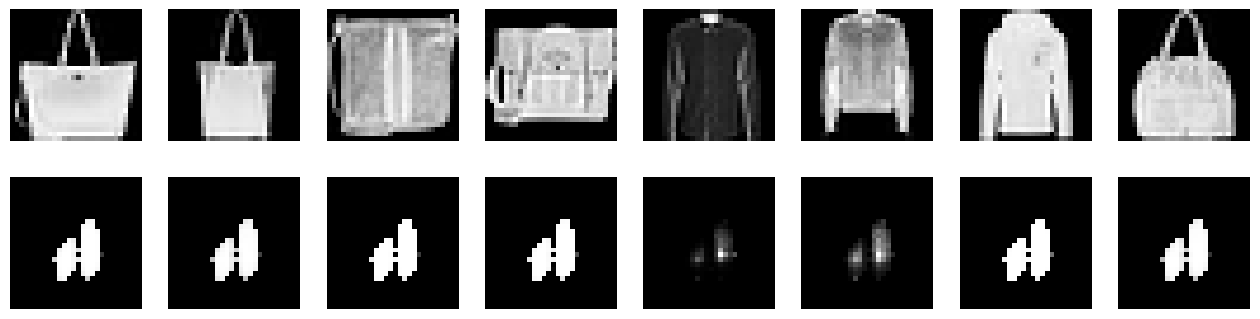

In [234]:
show_reconstructions(model, val_loader, device, n=8, save_path=save_dir / "images/reconstructions_epoch_01.png")

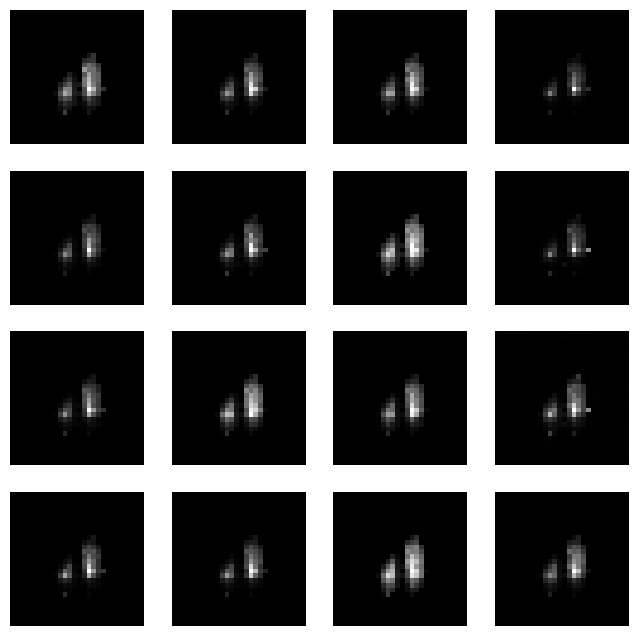

In [235]:
show_prior_samples(model, device, n=16, save_path=save_dir / "images/prior_samples_epoch_01.png")

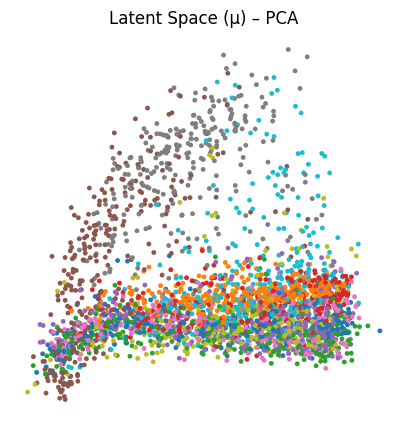

In [236]:
latent_scatter(model, val_loader, device, n=3000, method="pca", save_path=save_dir / "images/latent_scatter_epoch_01.png")

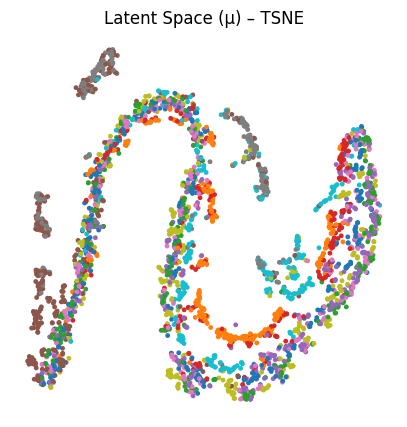

In [237]:
latent_scatter(model, val_loader, device, n=3000, method="tsne", save_path=save_dir / "images/latent_scatter_epoch_01_tsne.png")

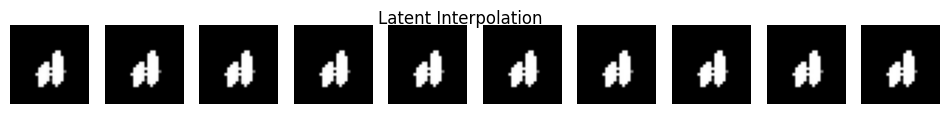

In [238]:
interpolate_between(model, val_loader, device, steps=10, save_path=save_dir / "images/latent_interpolation_epoch_01.png")

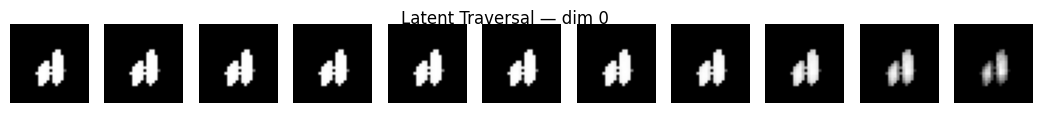

In [239]:
latent_traversal(model, val_loader, device, dim=0, span=3.0, steps=11, save_path=save_dir / "images/latent_traversal_dim0_epoch_01.png")

In [240]:
metrics = evaluate_metrics(model, val_loader, device)
print("Evaluation Metrics at Epoch 01:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

Evaluation Metrics at Epoch 01:
  recon: 537.4868
  kl: 5.8462
  nelbo: 543.3329
  bpd: 0.9998


### Visualizing Best Epoch Metrics

In [241]:
model.load_state_dict(torch.load(save_dir / "model/vae_fashion_mnist_best.pth"))

<All keys matched successfully>

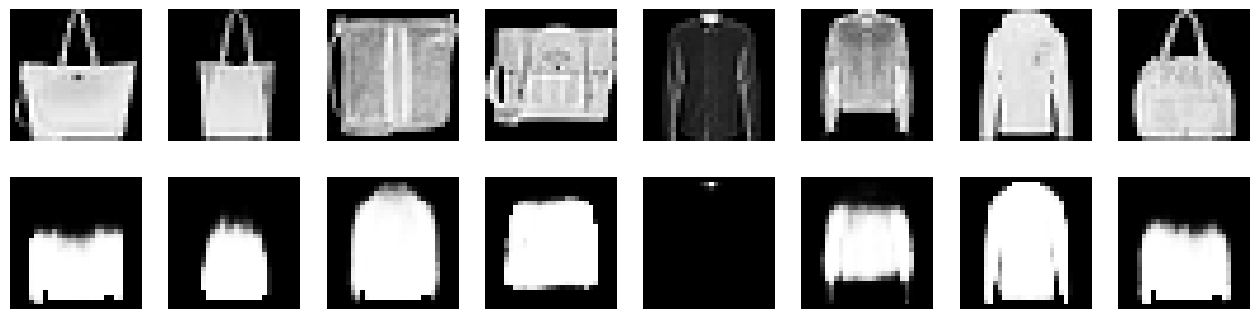

In [242]:
show_reconstructions(model, val_loader, device, n=8, save_path=save_dir / "images/reconstructions_best.png")

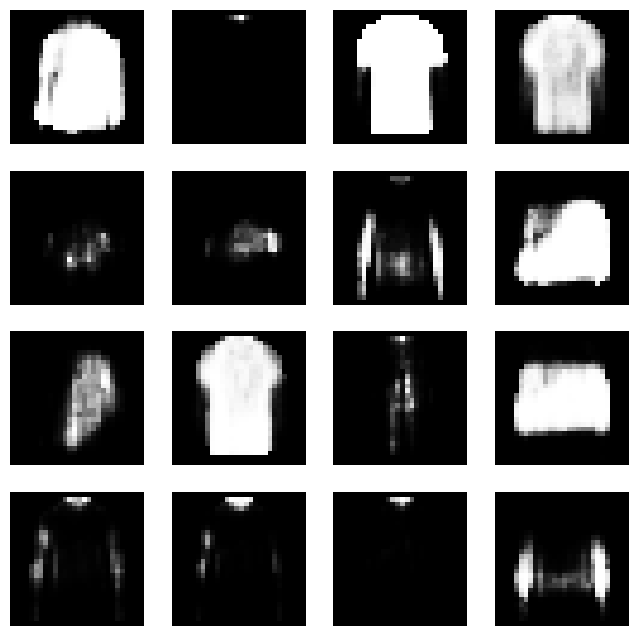

In [243]:
show_prior_samples(model, device, n=16, save_path=save_dir / "images/prior_samples_best.png")

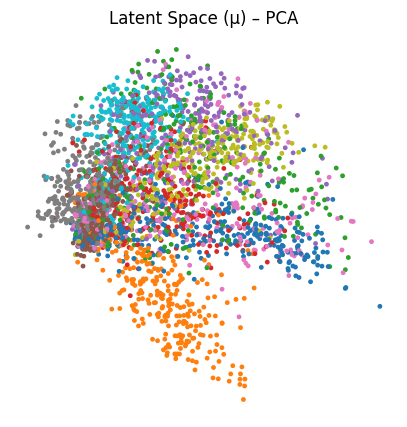

In [244]:
latent_scatter(model, val_loader, device, n=3000, method="pca", save_path=save_dir / "images/latent_scatter_best.png")

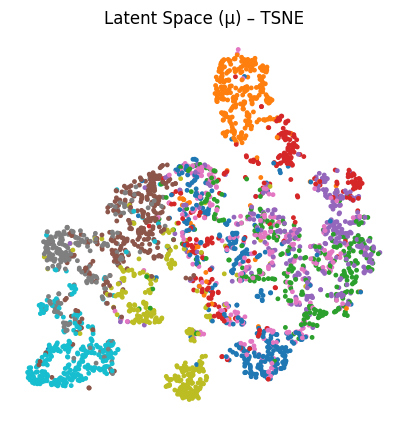

In [245]:
latent_scatter(model, val_loader, device, n=3000, method="tsne", save_path=save_dir / "images/latent_scatter_best_tsne.png")

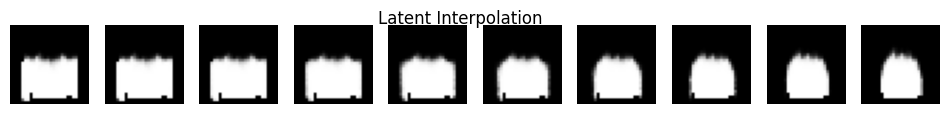

In [246]:
interpolate_between(model, val_loader, device, steps=10, save_path=save_dir / "images/latent_interpolation_epoch_best.png")

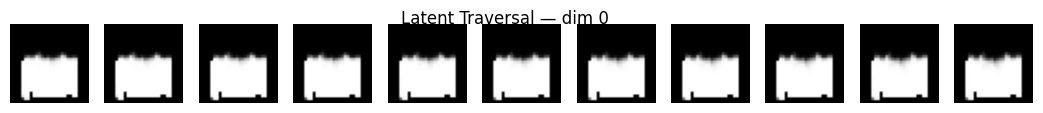

In [247]:
latent_traversal(model, val_loader, device, dim=0, span=3.0, steps=11, save_path=save_dir / "images/latent_traversal_best.png")

In [248]:
metrics = evaluate_metrics(model, val_loader, device)
print("Evaluation Metrics at Best Epoch:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

Evaluation Metrics at Best Epoch:
  recon: 516.1980
  kl: 7.9583
  nelbo: 524.1563
  bpd: 0.9645
